In [1]:
from modules.data_preparation import CreationClipDataset,CreationProcessedDataset,CLIPCollateFunction,split_clip_embeddings
from modules.inference import MemeDetector
from modules.extraction import CLIPExtractor
from modules.model import Train,Test,HeadClassifierCLIPModel
from torch.utils.data import Dataset, DataLoader
from transformers import CLIPProcessor,CLIPImageProcessor,CLIPTokenizerFast,CLIPModel
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
from torch.nn.modules.loss import CrossEntropyLoss
import torch
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import pandas as pd
import sys
import os
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score,roc_curve,RocCurveDisplay
current_dir = os.getcwd()
sys.path.append(os.path.abspath(os.path.join(os.path.dirname(current_dir), "..")))
from common_files import split,creation_dataframe,seed_worker,set_seed


In [2]:
seed=42
set_seed(seed=seed)

In [3]:
#Creation of the dataframes
train_df=creation_dataframe("../data/train.jsonl")

val_df=creation_dataframe("../data/dev.jsonl")

In [4]:
#Creation of the first Clip Datasets to get the texts and images embeddings through the pretrained clip model
train_clip_dataset=CreationClipDataset(train_df)
val_clip_dataset=CreationClipDataset(val_df)

In [5]:
#Initialisation of Clip Processors
#text_processor=CLIPTokenizerFast.from_pretrained("openai/clip-vit-base-patch32")
#image_processor=CLIPImageProcessor.from_pretrained("openai/clip-vit-base-patch32")
processor=CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


In [6]:
#Initialisation of the clip model, the device, and the batch size
clip_model=CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
device = (torch.device("mps") if torch.backends.mps.is_available() else torch.device("cuda" if torch.cuda.is_available() else "cpu"))
batch_size=32

In [7]:
clip_collate_object=CLIPCollateFunction(processor)

In [8]:
#Creation of the first Clip Dataloaders to get the texts and images embeddings through the pretrained clip model
generator=torch.Generator()
generator.manual_seed(seed)
train_clip_dataloader=DataLoader(train_clip_dataset,batch_size=batch_size,shuffle=False,collate_fn=clip_collate_object.collate_fn,generator=generator,worker_init_fn=seed_worker)
val_clip_dataloader=DataLoader(val_clip_dataset,batch_size=batch_size,shuffle=False,collate_fn=clip_collate_object.collate_fn,generator=generator,worker_init_fn=seed_worker)

In [9]:
clip_extractor=CLIPExtractor(clip_model,device)

In [11]:
#Extraction of the pretrained CLIP embeddings (texts embeddings, images embeddings, and similarity scores)
#final_train_data=clip_extractor.get_embeddings(train_clip_dataloader,"train","./modules/clip_embeddings")
#final_val_data=clip_extractor.get_embeddings(val_clip_dataloader,"val","./modules/clip_embeddings")

In [10]:
original_train_data=torch.load("./modules/clip_embeddings/train_clip_embeddings.pt")
val_data=torch.load("./modules/clip_embeddings/val_clip_embeddings.pt")

In [11]:
original_train_data["sim_scores"]=original_train_data["sim_scores"].view(-1,1)
val_data["sim_scores"]=val_data["sim_scores"].view(-1,1)

print(original_train_data["sim_scores"].shape)
print(val_data["sim_scores"].shape)

torch.Size([8500, 1])
torch.Size([500, 1])


In [12]:
train_data,test_data=split_clip_embeddings(original_train_data,seed=seed)

In [15]:
#Creation of final datasets and dataloaders for the training
batch_size=32
train_dataset=CreationProcessedDataset(train_data)
val_dataset=CreationProcessedDataset(val_data)
train_dataloader=DataLoader(train_dataset,batch_size=batch_size,shuffle=True,drop_last=True,generator=generator,worker_init_fn=seed_worker)
val_dataloader=DataLoader(val_dataset,batch_size=batch_size,shuffle=True,drop_last=True,generator=generator,worker_init_fn=seed_worker)

In [14]:
#Use of the class weights to compensate imabalances of the dataset and make more accurate predictions
class_weight=compute_class_weight("balanced",classes=np.unique(train_data["labels"].numpy()),y=train_data["labels"].numpy())
class_weight=torch.tensor(class_weight,dtype=torch.float32)
print(class_weight)

tensor([0.7798, 1.3934])


In [15]:
#Training hyperparameters
model=HeadClassifierCLIPModel(fc_layer_sizes=[512],with_scores=False)
n_epochs=11
n_steps=len(train_dataloader)*n_epochs
num_warmup_steps=int(0.1*n_steps)
optimizer=AdamW(model.parameters(),lr=0.01,weight_decay=5e-4)
scheduler=get_linear_schedule_with_warmup(optimizer,num_warmup_steps=num_warmup_steps,num_training_steps=n_steps)
loss_fn=CrossEntropyLoss(weight=class_weight)
trainer=Train(model,loss_fn,optimizer,n_epochs,scheduler,device)
trainer.run_training(train_dataloader,val_dataloader,"./train_savings/without_sim_scores")

2026-05-02 09:38:44.775 | INFO     | modules.model.train:run_training:99 - Epoch 0 :


2026-05-02 09:38:47.291 | INFO     | modules.model.train:run_training:170 - Epoch 0: Train Loss = 0.6380386171729994
2026-05-02 09:38:47.292 | INFO     | modules.model.train:run_training:171 - Epoch 0: Train Accuracy = 0.6461820083682008
2026-05-02 09:38:47.293 | INFO     | modules.model.train:run_training:172 - Epoch 0: Train F1 = 0.6523901893657468
2026-05-02 09:38:47.293 | INFO     | modules.model.train:run_training:174 - Epoch 0: Validation Loss = 0.6188564280668895
2026-05-02 09:38:47.294 | INFO     | modules.model.train:run_training:175 - Epoch 0: Validation Accuracy = 0.5958333333333333
2026-05-02 09:38:47.294 | INFO     | modules.model.train:run_training:176 - Epoch 0: Validation F1 = 0.5668722380712647
2026-05-02 09:38:47.312 | INFO     | modules.model.train:run_training:99 - Epoch 1 :
2026-05-02 09:38:49.159 | INFO     | modules.model.train:run_training:170 - Epoch 1: Train Loss = 0.5778793586597283
2026-05-02 09:38:49.159 | INFO     | modules.model.train:run_training:171 - E

In [16]:
#Training hyperparameters
model=HeadClassifierCLIPModel(fc_layer_sizes=[512],with_scores=True)
n_epochs=11
n_steps=len(train_dataloader)*n_epochs
num_warmup_steps=int(0.1*n_steps)
optimizer=AdamW(model.parameters(),lr=0.01,weight_decay=5e-4)
scheduler=get_linear_schedule_with_warmup(optimizer,num_warmup_steps=num_warmup_steps,num_training_steps=n_steps)
loss_fn=CrossEntropyLoss(weight=class_weight)
trainer=Train(model,loss_fn,optimizer,n_epochs,scheduler,device)
trainer.run_training(train_dataloader,val_dataloader,"./train_savings/with_sim_scores",with_scores=True)

2026-05-02 09:38:58.993 | INFO     | modules.model.train:run_training:99 - Epoch 0 :
2026-05-02 09:39:01.379 | INFO     | modules.model.train:run_training:170 - Epoch 0: Train Loss = 0.7218066496330325
2026-05-02 09:39:01.379 | INFO     | modules.model.train:run_training:171 - Epoch 0: Train Accuracy = 0.5118985355648535
2026-05-02 09:39:01.379 | INFO     | modules.model.train:run_training:172 - Epoch 0: Train F1 = 0.5218140609107672
2026-05-02 09:39:01.382 | INFO     | modules.model.train:run_training:174 - Epoch 0: Validation Loss = 0.6741400400797526
2026-05-02 09:39:01.383 | INFO     | modules.model.train:run_training:175 - Epoch 0: Validation Accuracy = 0.49375
2026-05-02 09:39:01.383 | INFO     | modules.model.train:run_training:176 - Epoch 0: Validation F1 = 0.32641213389121343
2026-05-02 09:39:01.396 | INFO     | modules.model.train:run_training:99 - Epoch 1 :
2026-05-02 09:39:03.620 | INFO     | modules.model.train:run_training:170 - Epoch 1: Train Loss = 0.7071267296579592
20

## Test Phase

In [13]:
batch_size=32
device = (torch.device("mps") if torch.backends.mps.is_available() else torch.device("cuda" if torch.cuda.is_available() else "cpu"))
test_dataset=CreationProcessedDataset(test_data)
generator=torch.Generator()
generator.manual_seed(seed)
class_weight=compute_class_weight("balanced",classes=np.unique(train_data["labels"].numpy()),y=train_data["labels"].numpy())
class_weight=torch.tensor(class_weight,dtype=torch.float32)
loss_fn=CrossEntropyLoss(weight=class_weight)
test_dataloader=DataLoader(test_dataset,batch_size=32,shuffle=True,drop_last=True,generator=generator,worker_init_fn=seed_worker)

## Test of the model without sim scores

In [14]:
path="./test_savings/without_sim_scores"
model=HeadClassifierCLIPModel(fc_layer_sizes=[512],with_scores=False)
model_parameters=torch.load("./train_savings/without_sim_scores/model_state.pt")
model.load_state_dict(model_parameters)
tester=Test(model,device,loss_fn)
f1,accuracy,final_loss,all_predictions,all_targets,log_probs=tester.run_testing(test_dataloader,path=path,with_scores=False)

2026-05-02 09:54:19.201 | INFO     | modules.model.test:run_testing:27 - Testing run:


2026-05-02 09:54:19.361 | INFO     | modules.model.test:run_testing:62 - Test Loss = 0.588040332381542
2026-05-02 09:54:19.361 | INFO     | modules.model.test:run_testing:63 - Test F1 Score = 0.6990994267134423
2026-05-02 09:54:19.361 | INFO     | modules.model.test:run_testing:64 - Test Accuracy: = 0.6971153846153846


The AUC score is 0.7577380952380953


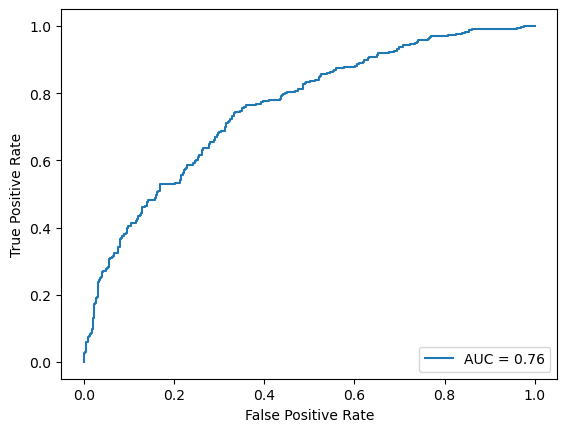

<function roc_auc_score at 0x000001D059775440>


In [17]:
performances=torch.load("./test_savings/without_sim_scores/test_performances.pt",weights_only=False)
targets=performances["targets"]
log_probs=performances["log_probs"][:,1]
fpr, tpr, thresholds=roc_curve(targets,log_probs)
roc_auc=roc_auc_score(targets,log_probs)
display=RocCurveDisplay(fpr=fpr,tpr=tpr,roc_auc=roc_auc)
print(f"The AUC score is {roc_auc}")
display.plot()
plt.show()
print(roc_auc_score)

The meme is :


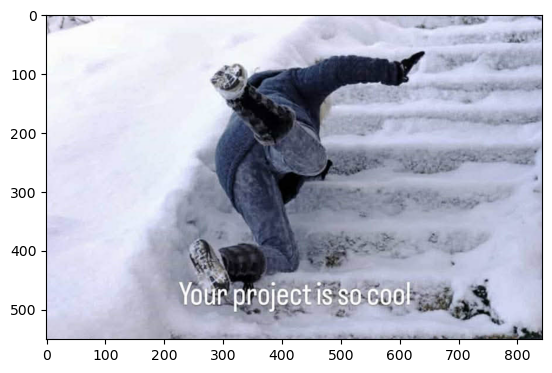

---------------------------
The text of the meme is :
'Your project is so cool'
---------------------------
Classification: The meme is lovely


In [18]:
meme_detector=MemeDetector(model=model,clip_processor=processor,clip_model=clip_model)
image_path="../meme.jpg"
meme_text="Your project is so cool"
meme_detector.detection(image_path,meme_text,with_sim_score=False)

## Test of the model with sim scores

In [20]:
path="./test_savings/with_sim_scores"
model=HeadClassifierCLIPModel(fc_layer_sizes=[512],with_scores=True)
model_parameters=torch.load("./train_savings/with_sim_scores/model_state.pt")
model.load_state_dict(model_parameters)
tester=Test(model,device,loss_fn)
f1,accuracy,final_loss,all_predictions,all_targets,log_probs=tester.run_testing(test_dataloader,path=path,with_scores=True)

2026-05-02 10:01:29.727 | INFO     | modules.model.test:run_testing:27 - Testing run:
2026-05-02 10:01:29.923 | INFO     | modules.model.test:run_testing:62 - Test Loss = 0.5901470367725079
2026-05-02 10:01:29.923 | INFO     | modules.model.test:run_testing:63 - Test F1 Score = 0.6804214927451728
2026-05-02 10:01:29.923 | INFO     | modules.model.test:run_testing:64 - Test Accuracy: = 0.6742788461538461


The AUC score is 0.7714959809747313


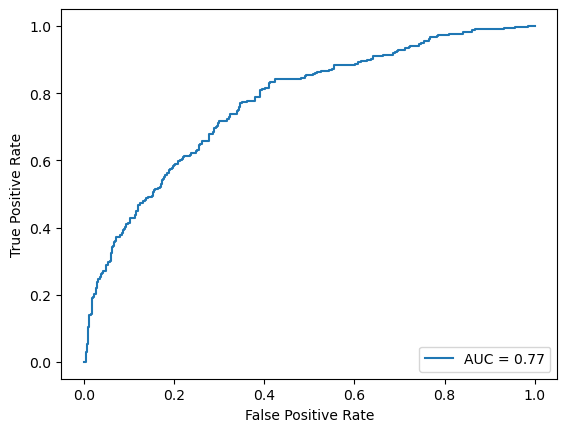

<function roc_auc_score at 0x000001D059775440>


In [21]:
performances=torch.load("./test_savings/with_sim_scores/test_performances.pt",weights_only=False)
targets=performances["targets"]
log_probs=performances["log_probs"][:,1]
fpr, tpr, thresholds=roc_curve(targets,log_probs)
roc_auc=roc_auc_score(targets,log_probs)
display=RocCurveDisplay(fpr=fpr,tpr=tpr,roc_auc=roc_auc)
print(f"The AUC score is {roc_auc}")
display.plot()
plt.show()
print(roc_auc_score)

The meme is :


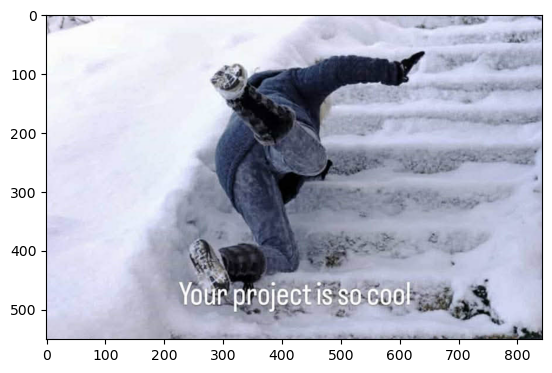

---------------------------
The text of the meme is :
'Your project is so cool'
---------------------------
Classification: The meme is lovely


In [22]:
meme_detector=MemeDetector(model=model,clip_processor=processor,clip_model=clip_model)
image_path="../meme.jpg"
meme_text="Your project is so cool"
meme_detector.detection(image_path,meme_text,with_sim_score=True)